# Thesis Metrics — Extraction Evaluation Charts


In [17]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.25,
})

C_GPT    = '#2563EB'   # blue  — GPT-4o
C_CLAUDE = '#16A34A'   # green — Claude Sonnet 4.6

with open('reports/results_openai.json', encoding='utf-8') as f:
    raw_gpt = json.load(f)
with open('reports/results_anthropic.json', encoding='utf-8') as f:
    raw_cld = json.load(f)

print(f'GPT-4o:        {len(raw_gpt)} scenarios')
print(f'Claude Sonnet: {len(raw_cld)} scenarios')


GPT-4o:        177 scenarios
Claude Sonnet: 177 scenarios


## Build DataFrames

In [18]:
GROUP_MAP = {
    'ext': 'Basic extraction', 'ext2': 'Basic extraction',
    'ext3': 'Basic extraction', 'ext4': 'Basic extraction',
    'conf': 'Confusion', 'conf2': 'Confusion', 'conf3': 'Confusion',
    'edge': 'Edge cases', 'edge2': 'Edge cases',
    'edge3': 'Edge cases', 'edge4': 'Edge cases',
    'multi': 'Multi-turn', 'multi2': 'Multi-turn',
    'multi3': 'Multi-turn', 'multi4': 'Multi-turn',
    'guard': 'Guardrail', 'guard2': 'Guardrail',
    'guard3': 'Guardrail', 'guard4': 'Guardrail',
    'stress': 'Stress tests',
}

def build(raw):
    recs, fields = [], []
    for r in raw:
        cat = r['category']
        recs.append({
            'id': r['id'], 'category': cat,
            'group': GROUP_MAP.get(cat, cat),
            'asserted': r['asserted'], 'correct': r['correct'], 'passed': r['passed'],
        })
        for fr in r.get('field_results', []):
            fields.append({
                'category': cat, 'group': GROUP_MAP.get(cat, cat),
                'field': fr['field'], 'ok': fr['ok'],
            })
    return pd.DataFrame(recs), pd.DataFrame(fields)

df_gpt, df_f_gpt = build(raw_gpt)
df_cld, df_f_cld = build(raw_cld)

def group_stats(df):
    g = df.groupby('group').agg(
        total=('passed','count'), passed=('passed','sum'),
        asserted=('asserted','sum'), correct=('correct','sum'),
    ).reset_index()
    g['pass_rate'] = g['passed'] / g['total'] * 100
    g['f1']        = g['correct'] / g['asserted'] * 100
    return g

def overall(df):
    return {
        'total': len(df),
        'passed': int(df['passed'].sum()),
        'total_f': int(df['asserted'].sum()),
        'correct_f': int(df['correct'].sum()),
        'pr': df['passed'].sum() / len(df) * 100,
        'f1': df['correct'].sum() / df['asserted'].sum() * 100,
    }

grp_gpt = group_stats(df_gpt)
grp_cld = group_stats(df_cld)
ov_gpt  = overall(df_gpt)
ov_cld  = overall(df_cld)

print(f"GPT-4o:        Pass Rate {ov_gpt['pr']:.1f}%  F1 {ov_gpt['f1']:.1f}%")
print(f"Claude Sonnet: Pass Rate {ov_cld['pr']:.1f}%  F1 {ov_cld['f1']:.1f}%")


GPT-4o:        Pass Rate 94.9%  F1 96.8%
Claude Sonnet: Pass Rate 97.7%  F1 99.5%


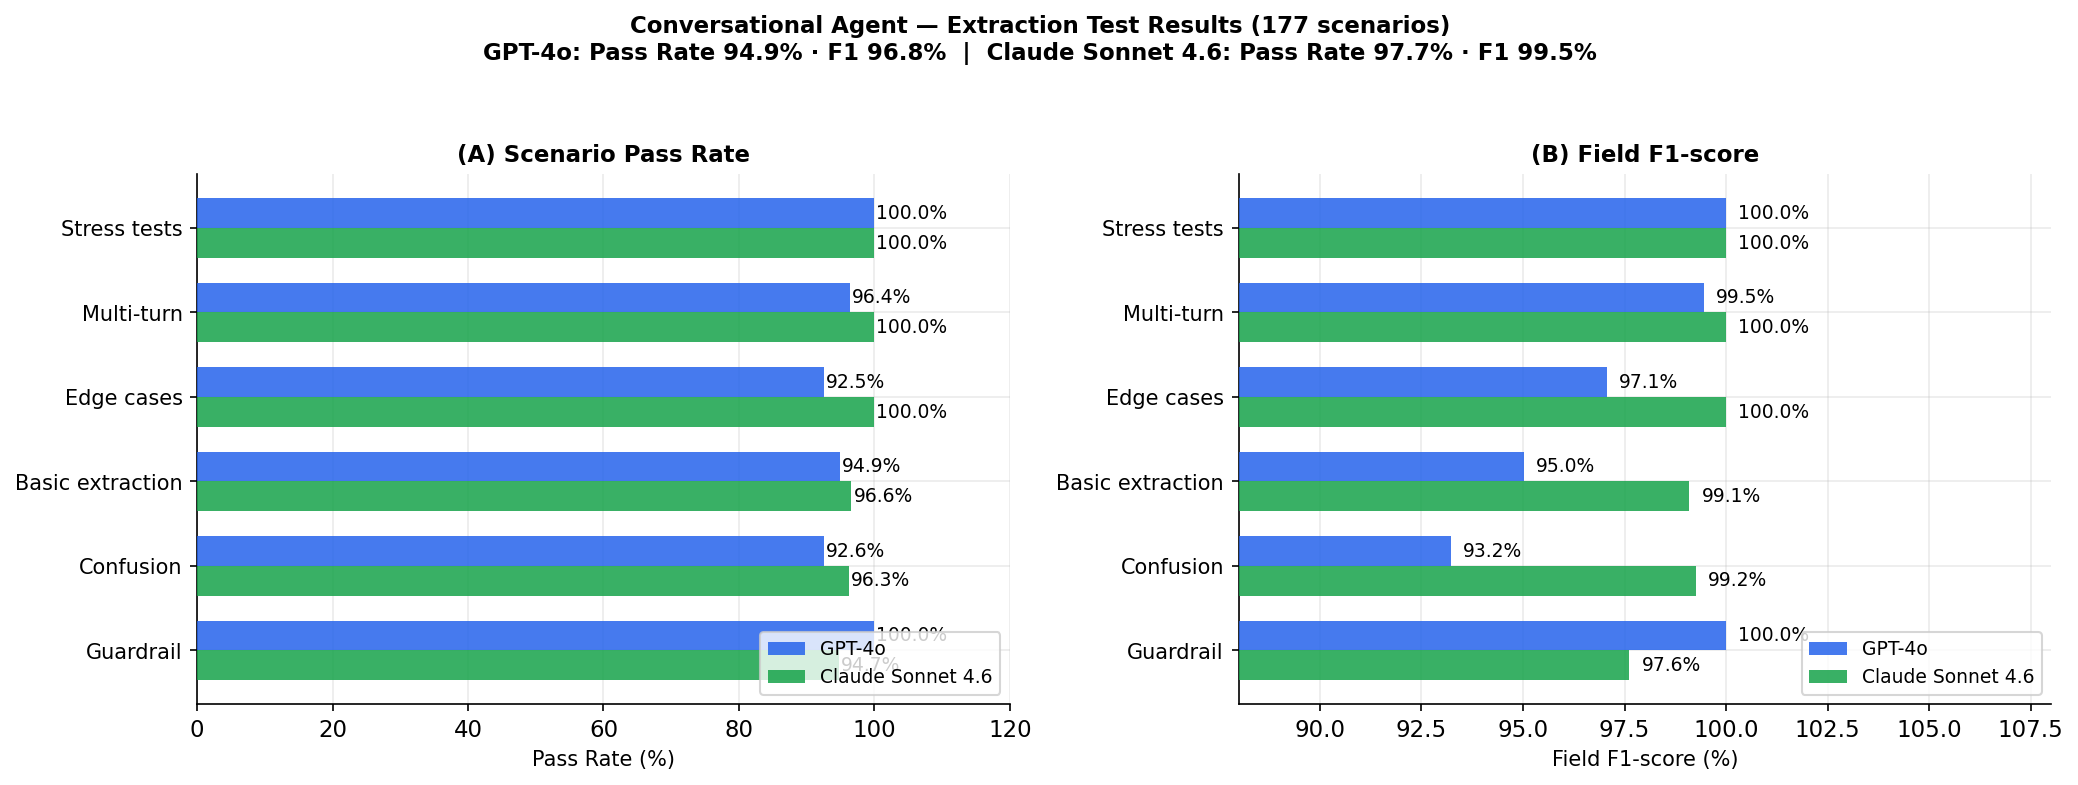

Saved: reports/extraction_comparison_2panel.png


In [19]:
# Merge groups sorted by Claude pass_rate descending
merged = grp_gpt[['group','pass_rate','f1']].rename(
    columns={'pass_rate':'pr_gpt','f1':'f1_gpt'}).merge(
    grp_cld[['group','pass_rate','f1']].rename(
    columns={'pass_rate':'pr_cld','f1':'f1_cld'}), on='group')
merged = merged.sort_values('pr_cld', ascending=True)

labels = merged['group'].tolist()
y = np.arange(len(labels))
h = 0.35

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

suptitle = (
    f"Conversational Agent — Extraction Test Results ({ov_gpt['total']} scenarios)\n"
    f"GPT-4o: Pass Rate {ov_gpt['pr']:.1f}% · F1 {ov_gpt['f1']:.1f}%"
    f"  |  Claude Sonnet 4.6: Pass Rate {ov_cld['pr']:.1f}% · F1 {ov_cld['f1']:.1f}%"
)
fig.suptitle(suptitle, fontsize=11, fontweight='bold', y=1.04)

for ax, gpt_col, cld_col, xlabel, xlim in [
    (ax_a, 'pr_gpt', 'pr_cld', 'Pass Rate (%)', (0, 120)),
    (ax_b, 'f1_gpt', 'f1_cld', 'Field F1-score (%)', (88, 108)),
]:
    b1 = ax.barh(y + h/2, merged[gpt_col], h, label='GPT-4o',
                 color=C_GPT, alpha=0.85, zorder=3)
    b2 = ax.barh(y - h/2, merged[cld_col], h, label='Claude Sonnet 4.6',
                 color=C_CLAUDE, alpha=0.85, zorder=3)
    for bar, val in zip(b1, merged[gpt_col]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    for bar, val in zip(b2, merged[cld_col]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(*xlim)
    ax.legend(fontsize=9, loc='lower right')

ax_a.set_title('(A) Scenario Pass Rate', fontsize=11, fontweight='bold')
ax_b.set_title('(B) Field F1-score', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/extraction_comparison_2panel.png', facecolor='white')
plt.show()
print('Saved: reports/extraction_comparison_2panel.png')


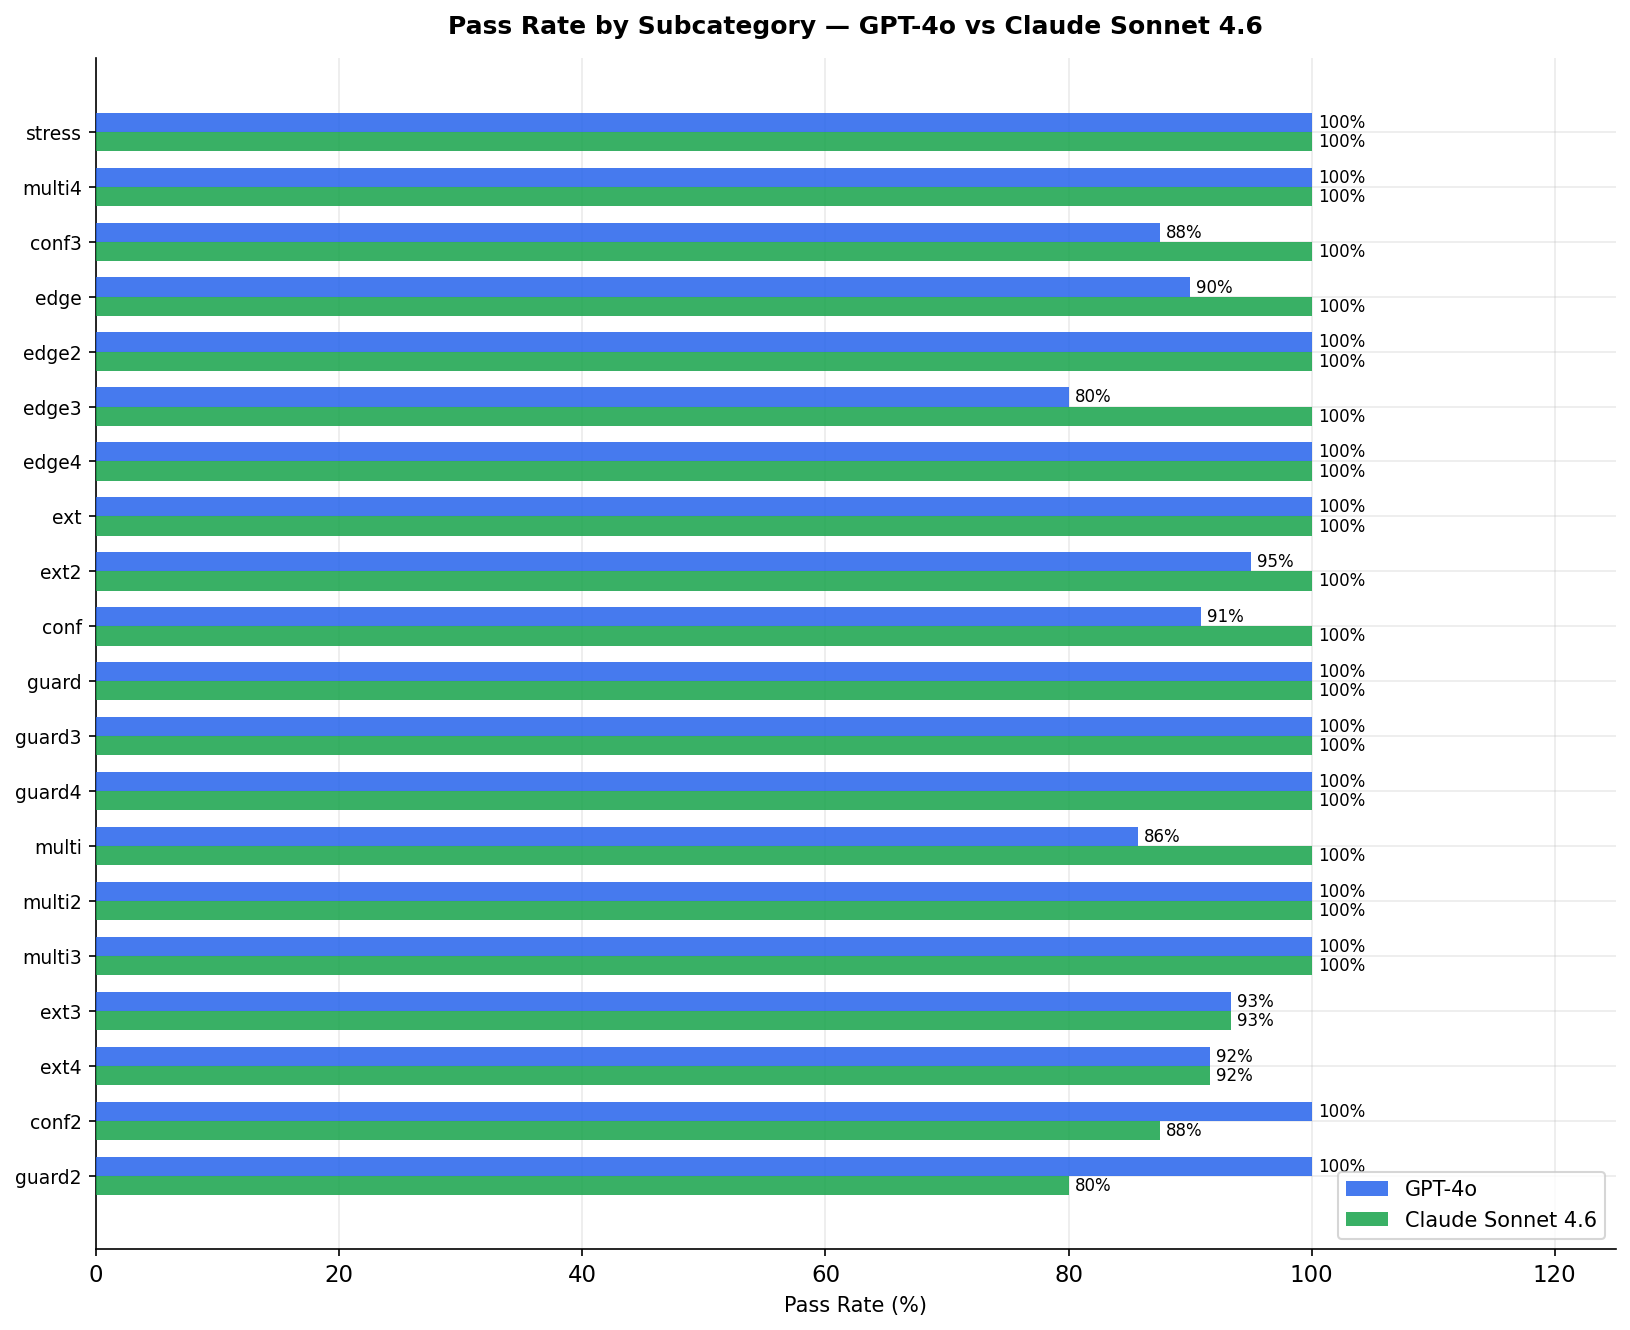

Saved: reports/appendix_subcategory_passrate.png


In [20]:
def cat_stats(df):
    g = df.groupby('category').agg(
        total=('passed','count'), passed=('passed','sum'),
    ).reset_index()
    g['pass_rate'] = g['passed'] / g['total'] * 100
    return g

cs_gpt = cat_stats(df_gpt)
cs_cld = cat_stats(df_cld)

mc = cs_gpt[['category','pass_rate']].rename(columns={'pass_rate':'pr_gpt'}).merge(
     cs_cld[['category','pass_rate']].rename(columns={'pass_rate':'pr_cld'}), on='category')
mc = mc.sort_values('pr_cld', ascending=True)

y = np.arange(len(mc))
h = 0.35

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')

b1 = ax.barh(y + h/2, mc['pr_gpt'], h, label='GPT-4o',        color=C_GPT,    alpha=0.85, zorder=3)
b2 = ax.barh(y - h/2, mc['pr_cld'], h, label='Claude Sonnet 4.6', color=C_CLAUDE, alpha=0.85, zorder=3)

for bar, val in zip(b1, mc['pr_gpt']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8)
for bar, val in zip(b2, mc['pr_cld']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(mc['category'], fontsize=9)
ax.set_xlim(0, 125)
ax.set_xlabel('Pass Rate (%)', fontsize=10)
ax.set_title('Pass Rate by Subcategory — GPT-4o vs Claude Sonnet 4.6',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('reports/appendix_subcategory_passrate.png', facecolor='white')
plt.show()
print('Saved: reports/appendix_subcategory_passrate.png')


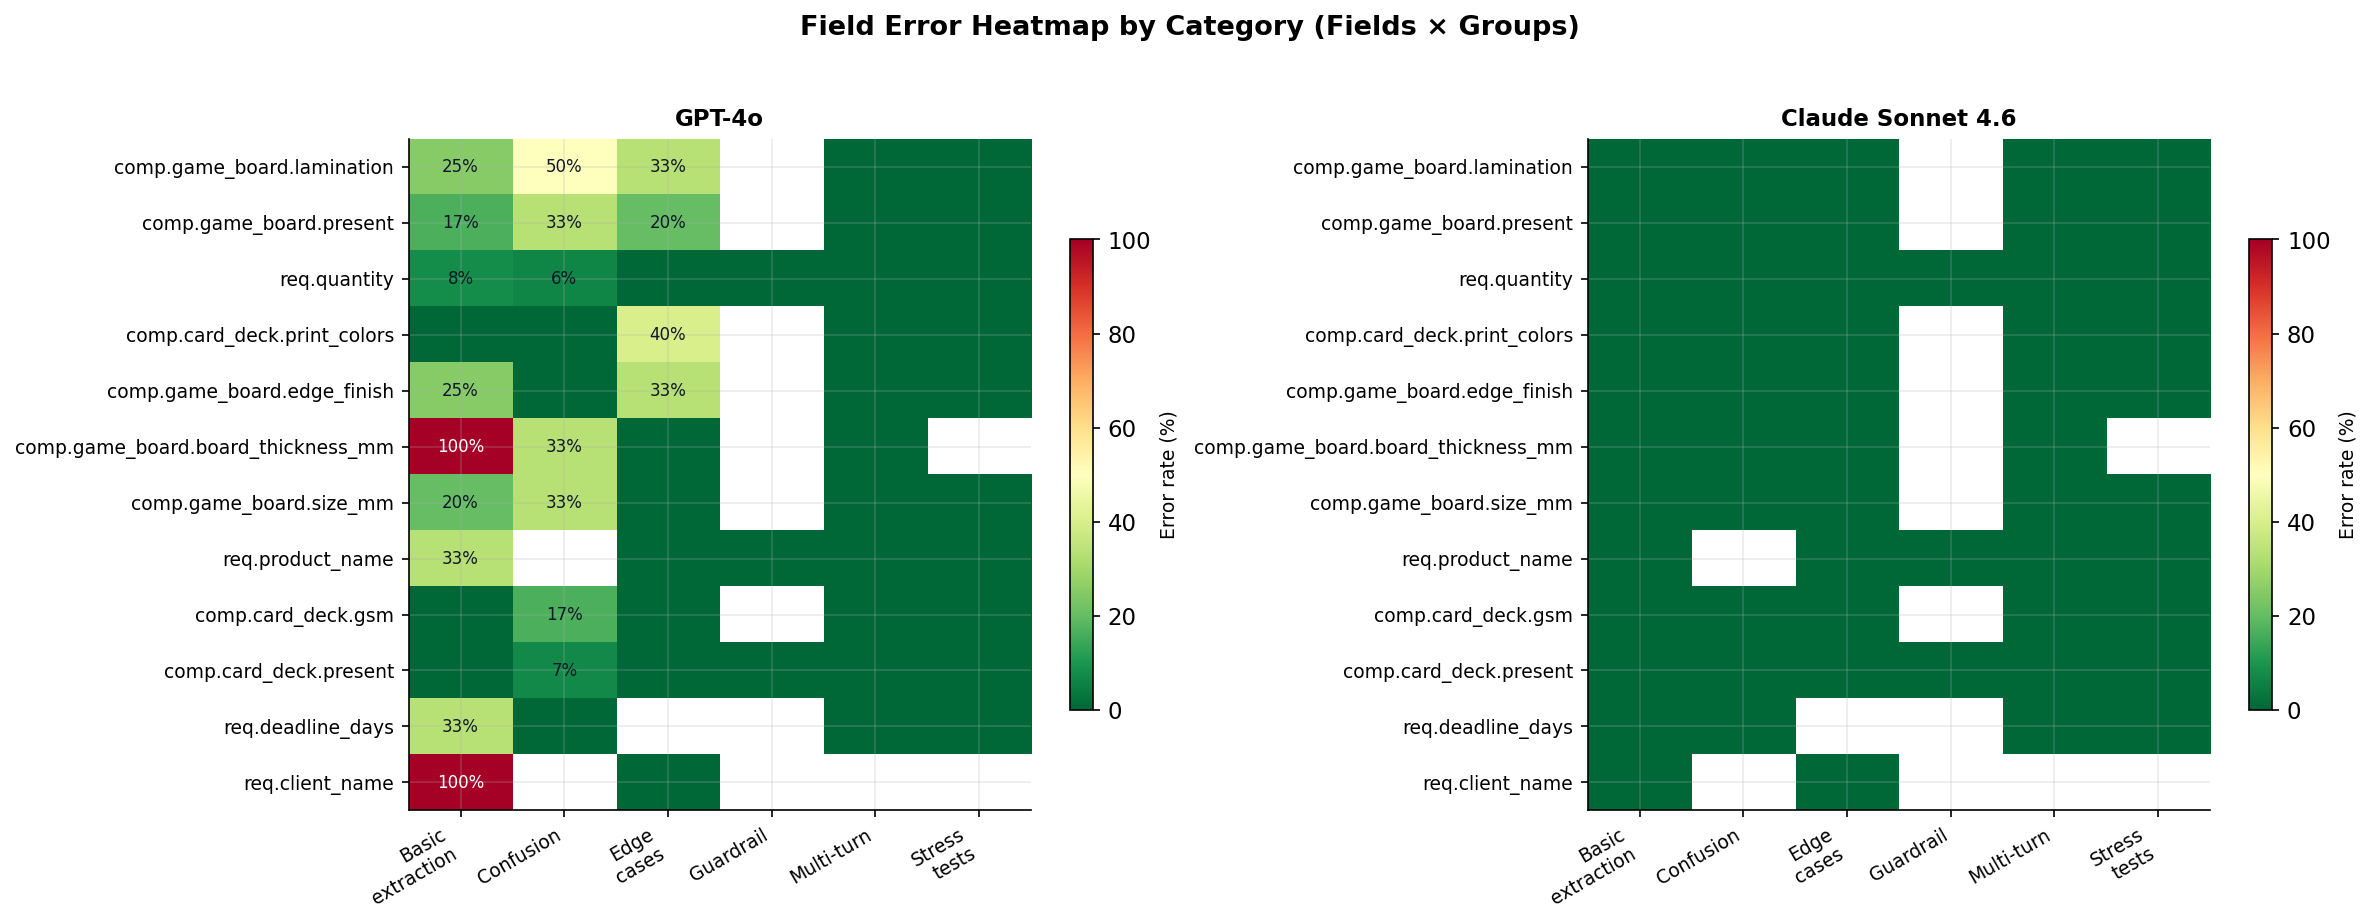

Saved: reports/appendix_field_heatmap.png


In [22]:
top_err_fields = top_fields[-12:]  # already sorted, take top-12

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

for ax, df_f, model_name in [
    (axes[0], df_f_gpt, 'GPT-4o'),
    (axes[1], df_f_cld, 'Claude Sonnet 4.6'),
]:
    heat = df_f[df_f['field'].isin(top_err_fields)].copy()
    heat['error'] = (~heat['ok']).astype(int)

    pivot = heat.pivot_table(values='error', index='field', columns='group',
                              aggfunc='sum', fill_value=0)
    total_p = heat.pivot_table(values='error', index='field', columns='group',
                                aggfunc='count', fill_value=0)
    pivot_norm = pivot / total_p.replace(0, np.nan) * 100

    # Reindex to consistent field order
    pivot_norm = pivot_norm.reindex(
        [f for f in reversed(top_err_fields) if f in pivot_norm.index])

    im = ax.imshow(pivot_norm.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=0, vmax=100)
    ax.set_xticks(range(len(pivot_norm.columns)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in pivot_norm.columns],
                        rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_norm.index)))
    ax.set_yticklabels(pivot_norm.index, fontsize=9)
    for i in range(pivot_norm.shape[0]):
        for j in range(pivot_norm.shape[1]):
            val = pivot_norm.values[i, j]
            if not np.isnan(val) and val > 0:
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=8, color='white' if val > 50 else '#111827')
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.7).set_label('Error rate (%)', fontsize=9)

fig.suptitle('Field Error Heatmap by Category (Fields × Groups)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/appendix_field_heatmap.png', facecolor='white')
plt.show()
print('Saved: reports/appendix_field_heatmap.png')
